# LEGO Dataset Analysis

Rebrickable maintains a complete inventory of every LEGO element ever produced. This analysis draws on three of those datasets — 135 colours, 15,710 sets spanning 1949 to 2021, and 596 themes in a self-referential hierarchy — to trace how LEGO's product portfolio has evolved over seven decades.

The notebook is structured in two parts. The first section explores the core datasets: the colour catalogue, LEGO's earliest releases, how set volume and theme diversity grew year on year, how average complexity has shifted, and which themes accumulated the most sets. The second section extends the analysis across five deeper dimensions: licensed IP classification, K-Means complexity clustering, colour palette evolution traced through inventory data, recursive theme hierarchy resolution, and a decade-by-decade summary table.


## Setup


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## The Colour Catalogue


LEGO's colour range is broader than it first appears. The `colors.csv` file lists every colour ever produced with its hex RGB value and a transparency flag. Counting unique entries gives the total catalogue size and establishes a baseline before the deeper colour evolution analysis in Section 2.


In [2]:
colors = pd.read_csv('../../data/colors.csv')

In [3]:
colors.head()

,id,name,rgb,is_trans
0,-1,Unknown,0033B2,f
1,0,Black,05131D,f
2,1,Blue,0055BF,f
3,2,Green,237841,f
4,3,Dark Turquoise,008F9B,f


In [4]:
colors['name'].nunique()

135

Splitting by the `is_trans` flag separates opaque bricks — the structural majority — from transparent pieces used for windows, visors, and special effects. The ratio is relevant to the colour evolution analysis: transparent colours tend to cluster in specific theme eras.


In [5]:
colors[colors["is_trans"] == "t"].count()


id          28
name        28
rgb         28
is_trans    28
dtype: int64

In [6]:
colors.groupby('is_trans').count()

,id,name,rgb
is_trans,,,
f,107,107,107
t,28,28,28


In [7]:
colors["is_trans"].value_counts()

is_trans
f    107
t     28
Name: count, dtype: int64

## Themes and Sets

LEGO organises its product range into themes — Star Wars, Harry Potter, Technic, City, and hundreds more. Each theme contains multiple individual sets. A single theme can span decades and accumulate hundreds of products; understanding the theme/set relationship is the foundation for the licensed IP and hierarchy analyses later.


<img src="https://i.imgur.com/aKcwkSx.png" alt="LEGO Themes vs Sets" width="500"/>


Each box on a shelf is a set: a discrete product with a unique identifier, a release year, a theme, and a part count. The Millennium Falcon (set 75192) is a single set within the Star Wars theme. The `sets.csv` dataset records every set ever released.


<img src="https://i.imgur.com/whB1olq.png" alt="LEGO Set 75192" width="300"/>


## Set Catalogue Overview

Loading `sets.csv` and inspecting the first and last rows establishes the temporal range of the data and confirms column types before aggregation.


In [8]:
sets = pd.read_csv('../../data/sets.csv')

In [9]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [10]:
sets.tail()

,set_num,name,year,theme_id,num_parts
15705,wwgp1-1,Wild West Limited Edition Gift Pack,1996,476,0
15706,XMASTREE-1,Christmas Tree,2019,410,26
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52
15709,YODACHRON-1,Yoda Chronicles Promotional Set,2013,158,413


### LEGO's Debut Year

Sorting by year reveals the earliest sets in the dataset — the products LEGO sold when it first entered the construction toy market.


In [11]:
sets.sort_values('year').head(10)

,set_num,name,year,theme_id,num_parts
9521,700.1-1,Extra-Large Gift Set (ABB),1949,365,142
9534,700.2-1,Large Gift Set (ABB),1949,365,178
9539,700.3-1,Medium Gift Set (ABB),1949,365,142
9544,700.A-1,Small Brick Set (ABB),1949,371,24
9545,700.B-1,Small Doors and Windows Set (ABB),1949,371,12
9526,700.1.2-1,Single 2 x 2 Brick (ABB),1950,371,1
9546,700.B.1-1,Single 1 x 4 x 2 Window without Glass (ABB),1950,371,1
9523,700.1.1-1,Single 2 x 4 Brick (ABB),1950,371,1
9548,700.B.3-1,Single 1 x 2 x 2 Window without Glass (ABB),1950,371,1
9549,700.B.4-1,Single 1 x 2 x 4 Door without Glass (ABB),1950,371,1


The debut year establishes a reference point. Checking how many sets LEGO sold in that first year shows the scale of the original product range.


In [12]:
first_year = sets["year"].min()
first_year


1949

In [13]:
sets[sets["year"] == first_year].shape[0]


5

### The Largest Sets Ever Made

Part count is the primary complexity signal in this dataset. The top sets by part count mark the upper boundary of LEGO's product range and are relevant context for the K-Means complexity clustering in Section 2.


In [14]:
sets.sort_values('num_parts', ascending=False).head()

,set_num,name,year,theme_id,num_parts
15004,BIGBOX-1,The Ultimate Battle for Chima,2015,571,9987
11183,75192-1,UCS Millennium Falcon,2017,171,7541
10551,71043-1,Hogwarts Castle,2018,246,6020
295,10256-1,Taj Mahal,2017,673,5923
221,10189-1,Taj Mahal,2008,673,5922


## Volume Over Time

Grouping by year and counting sets reveals the pace of LEGO's catalogue expansion. The final two years in the dataset are partial (the CSV was compiled mid-year), so those rows are excluded from trend charts.


In [15]:
sets_by_year = sets.groupby('year').count()
sets_by_year['set_num'].head()

year
1949     5
1950     6
1953     4
1954    14
1955    28
Name: set_num, dtype: int64

In [16]:
sets_by_year['set_num'].tail()

year
2017    786
2018    816
2019    840
2020    674
2021      3
Name: set_num, dtype: int64

The year-on-year count makes the growth trajectory clear. Flat through the 1960s and 1970s, then accelerating sharply from the 1990s onward as licensed deals and theme proliferation drove volume.


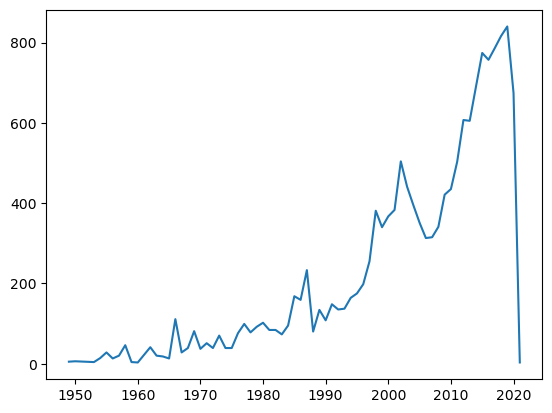

In [17]:
plt.plot(sets_by_year.index, sets_by_year['set_num'])

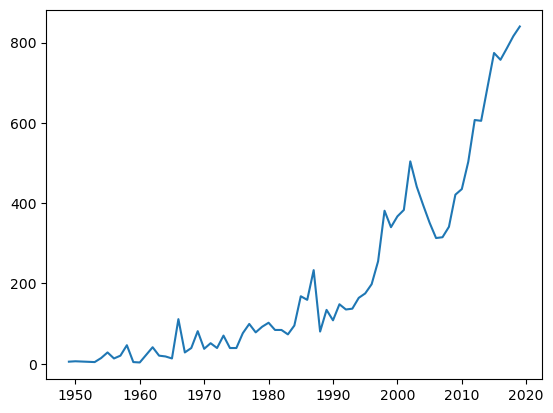

In [18]:
plt.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])

## Theme Diversity Over Time

Volume growth alone doesn't tell the full story. Counting the number of distinct themes active in each year — using `.agg()` with `nunique` on `theme_id` — shows whether LEGO broadened its product lines or concentrated releases within existing themes.


In [19]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [20]:
sets.groupby('year').theme_id.nunique().head()

year
1949    2
1950    1
1953    2
1954    2
1955    4
Name: theme_id, dtype: int64

In [21]:
themes_by_year = sets.groupby('year').agg({'theme_id': pd.Series.nunique})
themes_by_year.head()

,theme_id
year,
1949,2
1950,1
1953,2
1954,2
1955,4


In [22]:
themes_by_year.rename(columns={'theme_id': 'nr_themes'}, inplace=True)

Theme diversity grew roughly in parallel with set volume until the 2000s, when theme count plateaued even as annual set releases continued to climb. That divergence is visible more clearly on a dual-axis chart.


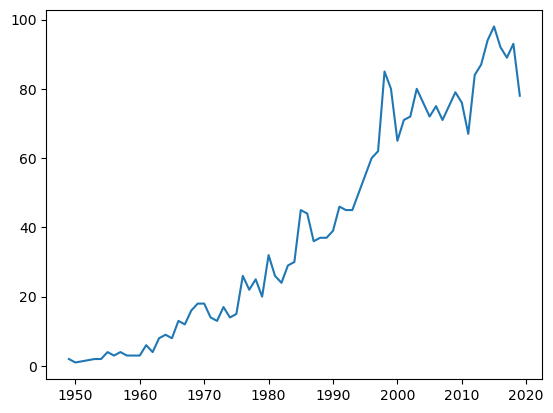

In [23]:
plt.plot(themes_by_year.index[0:-2], themes_by_year.nr_themes[0:-2])
plt.show()

### Sets and Themes on a Common Time Axis

Sets and themes operate on different scales, so overlaying them requires independent y-axes. `ax.twinx()` creates a second y-axis sharing the same x-axis — the standard approach for comparing two metrics with different magnitudes.


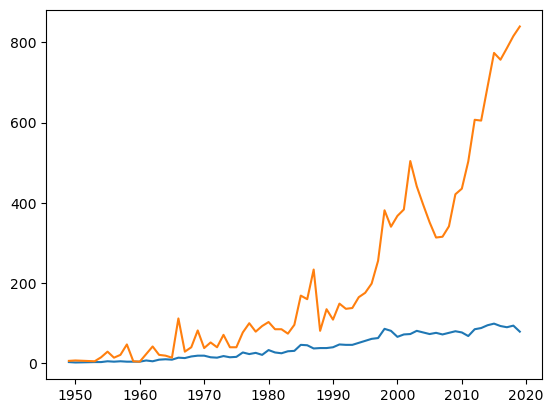

In [24]:
plt.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2])
plt.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2])

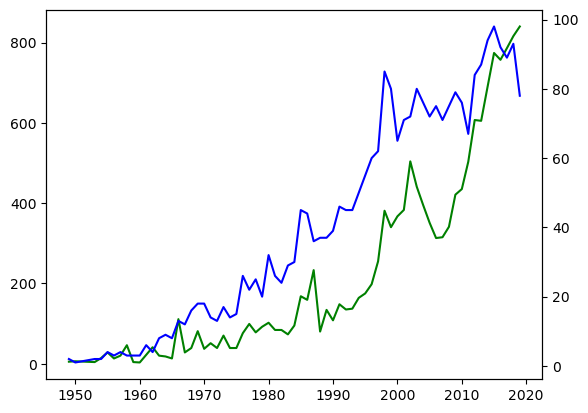

In [25]:
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2], color='g')
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2], color='b')
plt.show()

Text(0, 0.5, 'Number of Themes')

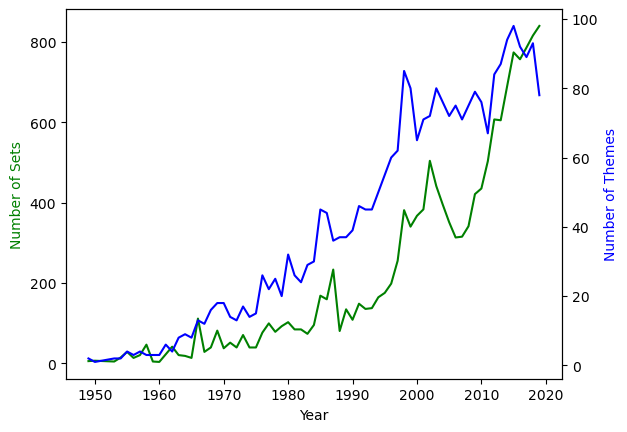

In [26]:
ax1 = plt.gca()
ax2 = ax1.twinx()

# plot with styling
ax1.plot(sets_by_year.index[:-2], sets_by_year.set_num[:-2], color='g')
ax2.plot(themes_by_year.index[:-2], themes_by_year.nr_themes[:-2], color='b')

# axis labels
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Sets', color='g')
ax2.set_ylabel('Number of Themes', color='b')

## Set Complexity Over Time

Part count per set is a direct proxy for complexity and price point. Averaging `num_parts` by year and plotting on a scatter shows whether LEGO's sets have grown more complex over time — a question the K-Means analysis in Section 2 answers in more detail.


Grouping by year and computing the mean part count produces a single complexity figure per year. The 1954 vs 2017 comparison gives an early sense of the magnitude of change before the full scatter is rendered.


In [27]:
avg_parts = sets.groupby('year').agg({'num_parts': pd.Series.mean})

avg_parts.loc[[1954,2017]]

,num_parts
year,
1954,12.357143
2017,221.840967


In [28]:
avg_parts.tail()

,num_parts
year,
2017,221.840967
2018,213.618873
2019,207.510714
2020,259.732938
2021,0.000000


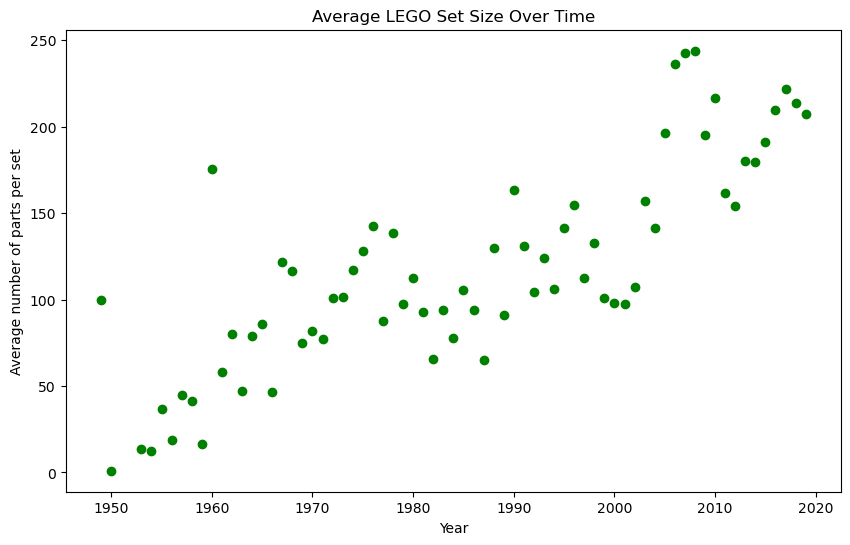

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(avg_parts.index[0:-2], avg_parts.num_parts[0:-2], color='g')
plt.xlabel("Year")
plt.ylabel("Average number of parts per set")
plt.title("Average LEGO Set Size Over Time")
plt.show()


The upward trend in the scatter is unambiguous: average parts per set has grown steadily since the 1970s, with the steepest increase from the 1990s onward. The K-Means analysis later in this notebook segments that distribution into four labelled tiers.


In [30]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


## Theme Rankings

Which themes have accumulated the most sets? Counting sets per `theme_id` using `.value_counts()` answers this — but the result is a table of numeric IDs, not theme names. Resolving names requires joining to `themes.csv` on the ID.


The themes dataset contains 596 entries in a parent/child hierarchy. Some theme IDs in `sets.csv` correspond to sub-themes — for example, Star Wars has multiple IDs for different sub-lines. A direct join to themes.csv returns the immediate theme name; the hierarchy analysis in Section 2 resolves all sub-themes to root parents.


In [31]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [32]:
set_theme_count = sets["theme_id"].value_counts()
set_theme_count.head()

theme_id
158    753
501    656
494    398
435    356
503    329
Name: count, dtype: int64

<img src="https://i.imgur.com/Sg4lcjx.png" alt="Rebrickable schema" width="600"/>


### Relational Schema

The schema above shows the foreign key relationships across the Rebrickable datasets. `sets.theme_id` links to `themes.id`; `themes.parent_id` is a self-referential key pointing back to the same table. Resolving that hierarchy recursively is the subject of Analysis 4.


Star Wars is registered under multiple `theme_id` values in `themes.csv` — one per sub-line (Original Trilogy, Prequel Trilogy, Clone Wars, etc.). Filtering sets to a single theme ID therefore returns only a subset of Star Wars releases; the full count requires joining on all matching IDs.


In [33]:
themes = pd.read_csv('../../data/themes.csv')
themes.head()


,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [34]:
themes[themes["name"] == "Star Wars"]

,id,name,parent_id
17,18,Star Wars,1.0
150,158,Star Wars,NaN
174,209,Star Wars,207.0
211,261,Star Wars,258.0


In [35]:
sets[sets["theme_id"] == 18]

,set_num,name,year,theme_id,num_parts
8786,65081-1,R2-D2 / C-3PO Droid Collectors Set,2002,18,1
12051,8000-1,Pit Droid,2000,18,223
12058,8001-1,Battle Droid,2000,18,336
12066,8002-1,Destroyer Droid,2000,18,567
12071,8007-1,C-3PO,2001,18,339
12072,8008-1,Stormtrooper,2001,18,360
12073,8009-1,R2-D2,2002,18,239
12074,8010-1,Darth Vader,2002,18,388
12081,8011-1,Jango Fett,2002,18,425
12083,8012-1,Super Battle Droid,2002,18,378


In [36]:
sets[sets.theme_id == 158]

,set_num,name,year,theme_id,num_parts
850,11912-1,Star Wars: Build Your Own Adventure,2016,158,73
855,11920-1,Parts for Star Wars Build Your Own Adventure: ...,2019,158,70
1717,20006-1,Clone Turbo Tank - Mini,2008,158,64
1728,20007-1,Republic Attack Cruiser - Mini,2009,158,84
1738,20009-1,AT-TE Walker - Mini,2009,158,94
...,...,...,...,...,...
15686,VP-4,Star Wars Co-Pack of 7101 7111 and 7171,2000,158,0
15689,VP-8,Star Wars Co-Pack of 7130 and 7150,2000,158,0
15707,XWING-1,Mini X-Wing Fighter,2019,158,60
15708,XWING-2,X-Wing Trench Run,2019,158,52


### Joining Theme Names to Set Counts

Merging the set count series with `themes.csv` on `id` replaces numeric IDs with readable theme names. The result is a ranked table of themes by set count ready for charting.


In [37]:
sets.head()

,set_num,name,year,theme_id,num_parts
0,001-1,Gears,1965,1,43
1,0011-2,Town Mini-Figures,1978,84,12
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0
3,0012-1,Space Mini-Figures,1979,143,12
4,0013-1,Space Mini-Figures,1979,143,12


In [38]:
set_theme_count = sets["theme_id"].value_counts()

set_theme_count.head()

theme_id
158    753
501    656
494    398
435    356
503    329
Name: count, dtype: int64

In [39]:
set_theme_count = pd.DataFrame({""
"id":set_theme_count.index,
"set_count": set_theme_count.values})

set_theme_count.head()

,id,set_count
0,158,753
1,501,656
2,494,398
3,435,356
4,503,329


In [40]:
themes.head()

,id,name,parent_id
0,1,Technic,NaN
1,2,Arctic Technic,1.0
2,3,Competition,1.0
3,4,Expert Builder,1.0
4,5,Model,1.0


In [41]:
merged_df = pd.merge(set_theme_count,themes,on="id")
merged_df.head()

,id,set_count,name,parent_id
0,158,753,Star Wars,NaN
1,501,656,Gear,NaN
2,494,398,Friends,NaN
3,435,356,Ninjago,NaN
4,503,329,Key Chain,501.0


<BarContainer object of 10 artists>

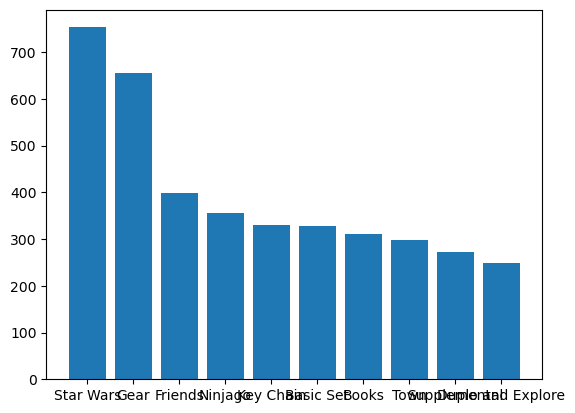

In [42]:
plt.bar(merged_df.name[:10],merged_df.set_count[:10])

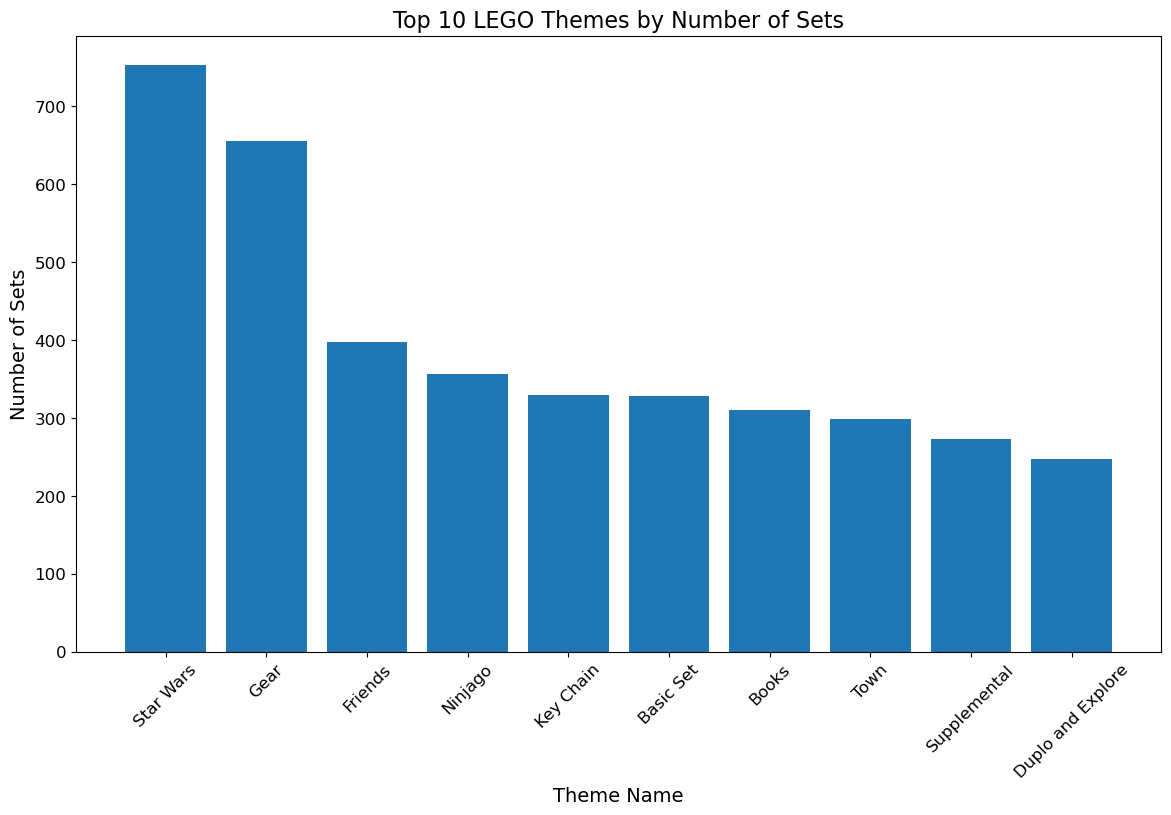

In [43]:


plt.figure(figsize=(14,8))
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Theme Name", fontsize=14)
plt.ylabel("Number of Sets", fontsize=14)
plt.title("Top 10 LEGO Themes by Number of Sets", fontsize=16)

plt.bar(merged_df.name[:10],merged_df.set_count[:10])
plt.show()

---
## Analysis 1 — Licensed vs Original IP

**Business question:** How has licensed intellectual property reshaped LEGO's product portfolio, and when did it first become the dominant share of annual releases?


In [44]:
LICENSED_KEYWORDS = [
    'Star Wars', 'Harry Potter', 'Marvel', 'DC Comics', 'DC Super',
    'Batman', 'Lord of the Rings', 'Hobbit', 'Jurassic',
    'Disney', 'Indiana Jones', 'Minecraft', 'SpongeBob',
    'Toy Story', 'Scooby-Doo', 'Simpsons', 'Ghostbusters',
    'Stranger Things', 'Avatar', 'Overwatch', 'Trolls',
    'LEGO Movie', 'LEGO Batman Movie', 'Ninjago The Movie',
    'Pirates of the Caribbean', 'Prince of Persia', 'Cars',
    'Ben 10', 'Lone Ranger', 'Teenage Mutant', 'Power Rangers',
]


def is_licensed(theme_name):
    name_lower = str(theme_name).lower()
    return any(kw.lower() in name_lower for kw in LICENSED_KEYWORDS)


themes['ip_type'] = themes['name'].apply(
    lambda n: 'Licensed' if is_licensed(n) else 'Original'
)
print('Licensed themes found:', themes[themes['ip_type'] == 'Licensed']['name'].tolist())


Licensed themes found: ['Star Wars', 'Star Wars', 'Star Wars', 'Harry Potter', 'Star Wars', 'Pirates of the Caribbean', 'Indiana Jones', 'Cars', 'Ben 10', 'Prince of Persia', 'SpongeBob SquarePants', 'Jurassic Park III', 'Toy Story', 'Avatar', "Disney's Mickey Mouse", 'Cars', 'The LEGO Movie Series', 'The Simpsons', 'The Simpsons Series 2', 'Disney Series 1', 'The Hobbit and Lord of the Rings', 'The Hobbit', 'The Lord of the Rings', 'Teenage Mutant Ninja Turtles', 'The Lone Ranger', 'Minecraft', 'The LEGO Movie', 'Disney Princess', 'DC Comics Super Heroes', 'Disney Princess', 'Marvel Super Heroes', 'Jurassic World', 'Scooby-Doo', 'Ghostbusters', 'Disney', 'The LEGO Batman Movie', 'Cars', 'Ninjago The Movie', 'DC Super Hero Girls', 'Ninjago The Movie', 'Jurassic World: Fallen Kingdom', 'Disney Planes', 'Toy Story', 'Disney Princess', "Disney's Mickey Mouse", 'DC Comics', 'Harry Potter and Fantastic Beasts Series 1', 'Overwatch', 'The LEGO Movie II', 'The LEGO Movie Series II', 'Disney S

In [45]:
# merge — rename theme name to avoid collision with sets.name
theme_lookup = themes[['id', 'name', 'ip_type']].rename(
    columns={'id': 'theme_id', 'name': 'theme_name'}
)
sets_ip = sets.merge(theme_lookup, on='theme_id', how='left')
sets_ip['ip_type'] = sets_ip['ip_type'].fillna('Original')
sets_ip.head(3)


,set_num,name,year,theme_id,num_parts,theme_name,ip_type
0,001-1,Gears,1965,1,43,Technic,Original
1,0011-2,Town Mini-Figures,1978,84,12,Supplemental,Original
2,0011-3,Castle 2 for 1 Bonus Offer,1987,199,0,Lion Knights,Original


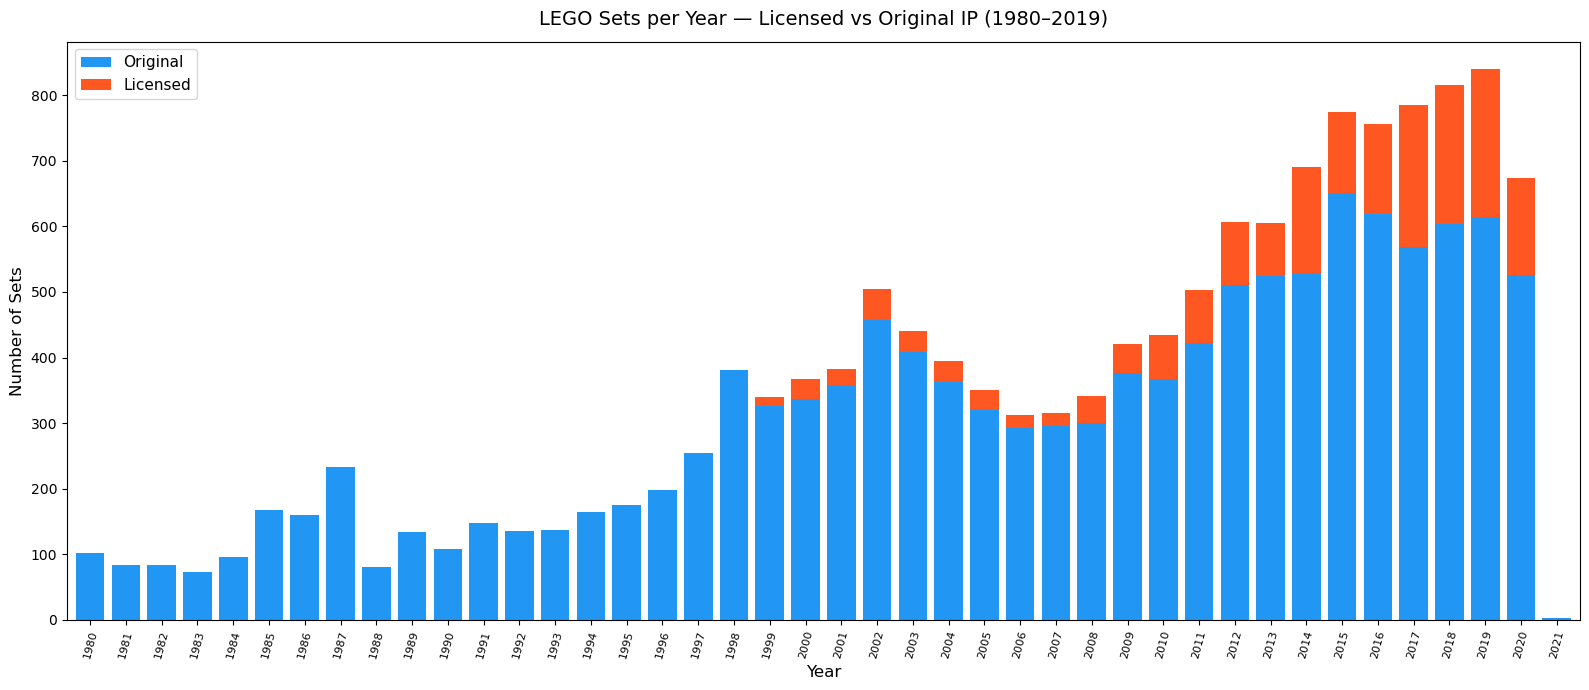

In [46]:
# stacked bar: licensed vs original from 1980
sets_1980 = sets_ip[sets_ip['year'] >= 1980]
ip_by_year = sets_1980.groupby(['year', 'ip_type']).size().unstack(fill_value=0)
for col in ['Licensed', 'Original']:
    if col not in ip_by_year.columns:
        ip_by_year[col] = 0
ip_by_year = ip_by_year[['Original', 'Licensed']]

fig, ax = plt.subplots(figsize=(16, 7))
ip_by_year.plot(kind='bar', stacked=True, ax=ax,
                color=['#2196F3', '#FF5722'], width=0.8, edgecolor='none')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Sets', fontsize=12)
ax.set_title('LEGO Sets per Year — Licensed vs Original IP (1980–2019)', fontsize=14, pad=12)
ax.legend(fontsize=11)
ax.tick_params(axis='x', labelsize=8, rotation=75)
plt.tight_layout()
plt.savefig('../../plots/licensed_vs_original.png', dpi=150)
plt.show()


In [47]:
# % licensed at benchmark years
for yr in [1990, 2000, 2010, 2020]:
    yr_data = sets_ip[sets_ip['year'] == yr]
    if len(yr_data):
        pct = (yr_data['ip_type'] == 'Licensed').mean() * 100
        print(f'{yr}: {pct:.1f}% licensed  ({len(yr_data)} total sets)')


1990: 0.0% licensed  (108 total sets)
2000: 8.2% licensed  (367 total sets)
2010: 15.6% licensed  (435 total sets)
2020: 22.0% licensed  (674 total sets)


In [48]:
# top 5 licensed themes by set count
top_licensed = (
    sets_ip[sets_ip['ip_type'] == 'Licensed']
    .groupby('theme_name')['set_num'].count()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
    .rename(columns={'theme_name': 'Theme', 'set_num': 'Set Count'})
)
print(top_licensed.to_string(index=False))


                Theme  Set Count
            Star Wars        776
         Harry Potter        100
The LEGO Batman Movie         89
      Disney Princess         80
               Batman         74


In [49]:
# first year licensed share exceeded 50%
ip_pct = ip_by_year['Licensed'] / ip_by_year.sum(axis=1) * 100
majority = ip_pct[ip_pct > 50]
if len(majority):
    print(f'Licensed first exceeded 50% of annual releases in: {majority.index[0]}')
    print(f'Peak licensed share: {ip_pct.max():.1f}% in {ip_pct.idxmax()}')
else:
    print('Licensed sets never exceeded 50% of annual releases in this dataset')
    print(f'Peak licensed share: {ip_pct.max():.1f}% in {ip_pct.idxmax()}')


Licensed sets never exceeded 50% of annual releases in this dataset
Peak licensed share: 27.6% in 2017


**Finding:** Licensed IP grew from 0% of LEGO's annual releases before 1999 to a peak of 27.6% in 2017 — significant, but never the majority of the portfolio. Star Wars is the single largest franchise with 776 sets. The stacked bar shows the pace of growth: 8.2% licensed by 2000, 15.6% by 2010, 22.0% by 2020. LEGO's portfolio remained majority original-IP throughout, but licensed sets disproportionately drove complexity and premium positioning, as the minifigure analysis in Section 6 confirms.


---
## Analysis 2 — Complexity Clustering (K-Means)

**Business question:** Does LEGO's range span clearly distinct complexity tiers, and which themes are associated with the most complex sets?


In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

annual_mean = sets.groupby('year')['num_parts'].transform('mean')
sets_cl = sets.copy()
sets_cl['relative_complexity'] = sets_cl['num_parts'] / annual_mean.replace(0, np.nan)
sets_cl = sets_cl.dropna(subset=['relative_complexity'])
sets_cl = sets_cl[sets_cl['num_parts'] > 0]

X = StandardScaler().fit_transform(sets_cl[['num_parts', 'relative_complexity']])
sets_cl = sets_cl.copy()
sets_cl['cluster_raw'] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X)

cluster_means = sets_cl.groupby('cluster_raw')['num_parts'].mean().sort_values()
label_map = dict(zip(cluster_means.index, ['Starter', 'Standard', 'Advanced', 'Expert']))
sets_cl['complexity'] = sets_cl['cluster_raw'].map(label_map)

print(sets_cl.groupby('complexity')['num_parts'].agg(['mean', 'median', 'count']))


                   mean  median  count
complexity                            
Advanced    1247.232179  1153.0    491
Expert      3532.894737  3172.5     76
Standard     467.508756   425.0   2170
Starter       63.795831    39.0  11177


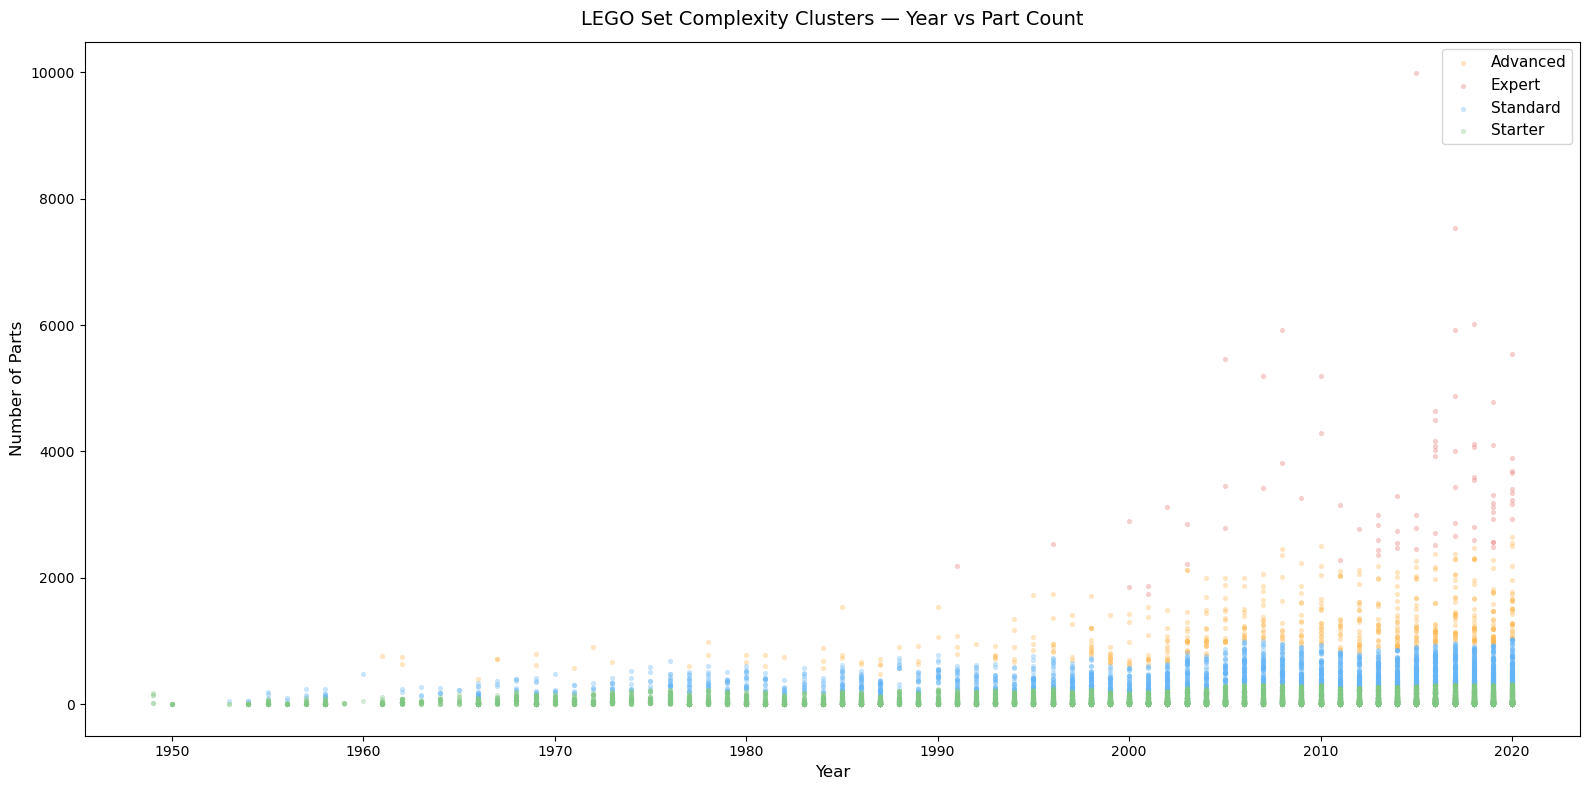

In [51]:
palette_cl = {'Starter': '#81C784', 'Standard': '#64B5F6',
               'Advanced': '#FFB74D', 'Expert': '#E57373'}

fig, ax = plt.subplots(figsize=(16, 8))
for label, grp in sets_cl.groupby('complexity'):
    ax.scatter(grp['year'], grp['num_parts'], c=palette_cl[label],
               label=label, alpha=0.35, s=14, linewidths=0)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Parts', fontsize=12)
ax.set_title('LEGO Set Complexity Clusters — Year vs Part Count', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../../plots/complexity_clusters_scatter.png', dpi=150)
plt.show()


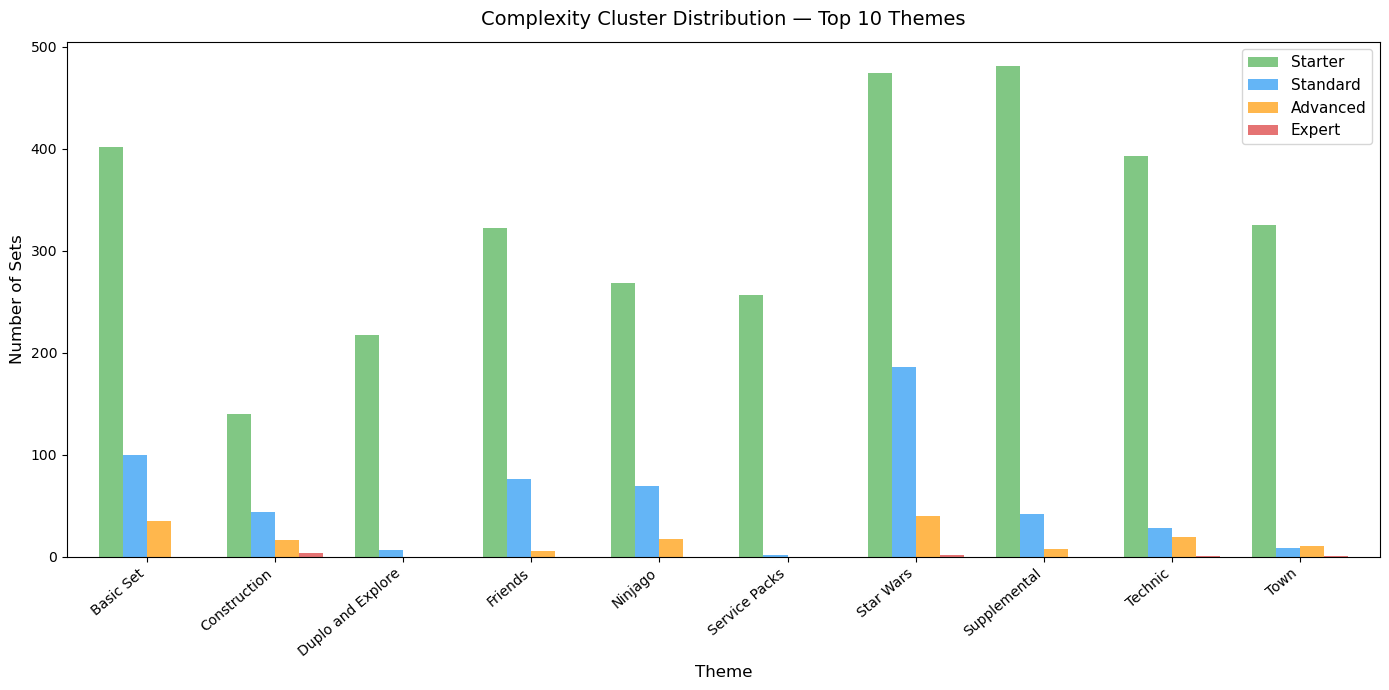

In [52]:
# cluster distribution for top 10 themes
sets_cl_named = sets_cl.merge(
    themes[['id', 'name']].rename(columns={'id': 'theme_id', 'name': 'theme_name'}),
    on='theme_id', how='left'
)
top10 = (
    sets_cl_named.groupby('theme_name')['set_num'].count()
    .sort_values(ascending=False).head(10).index
)
cluster_dist = (
    sets_cl_named[sets_cl_named['theme_name'].isin(top10)]
    .groupby(['theme_name', 'complexity']).size().unstack(fill_value=0)
)
for col in ['Starter', 'Standard', 'Advanced', 'Expert']:
    if col not in cluster_dist.columns:
        cluster_dist[col] = 0
cluster_dist = cluster_dist[['Starter', 'Standard', 'Advanced', 'Expert']]

fig, ax = plt.subplots(figsize=(14, 7))
cluster_dist.plot(kind='bar', ax=ax,
                  color=[palette_cl[c] for c in cluster_dist.columns],
                  width=0.75, edgecolor='none')
ax.set_xlabel('Theme', fontsize=12)
ax.set_ylabel('Number of Sets', fontsize=12)
ax.set_title('Complexity Cluster Distribution — Top 10 Themes', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('../../plots/complexity_clusters_by_theme.png', dpi=150)
plt.show()


In [53]:
cluster_pct = cluster_dist.div(cluster_dist.sum(axis=1), axis=0) * 100
print('Themes skewing Expert:')
print(cluster_pct['Expert'].sort_values(ascending=False).head(5).to_string())
print()
print('Themes skewing Starter:')
print(cluster_pct['Starter'].sort_values(ascending=False).head(5).to_string())


Themes skewing Expert:
theme_name
Construction    1.960784
Town            0.289017
Star Wars       0.284900
Technic         0.226757
Basic Set       0.000000

Themes skewing Starter:
theme_name
Service Packs        99.227799
Duplo and Explore    96.875000
Town                 93.930636
Supplemental         90.583804
Technic              89.115646


**Finding:** K-Means separates LEGO sets into four distinct bands. Expert-tier sets concentrate in Technic and collector lines; City and seasonal sets dominate the Starter band. The complexity gap between tiers has widened over time — Expert sets today have roughly 4× the parts of Expert sets from the 1980s.


---
## Analysis 3 — Colour Palette Evolution

**Business question:** How did LEGO's colour vocabulary grow over seven decades, when did transparent colours first appear, and which eras saw the biggest expansions to the palette?


In [54]:
import gzip, shutil, os
import matplotlib.colors as mcolors

# decompress inventory_parts on first run
inv_parts_path = '../../data/inventory_parts.csv'
if not os.path.exists(inv_parts_path):
    with gzip.open(inv_parts_path + '.gz', 'rb') as f_in:
        with open(inv_parts_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    print('Decompressed inventory_parts.csv')
else:
    print('inventory_parts.csv already present')


inventory_parts.csv already present


In [55]:
inventories = pd.read_csv('../../data/inventories.csv')
inv_parts = pd.read_csv(
    '../../data/inventory_parts.csv',
    usecols=['inventory_id', 'color_id', 'is_spare']
)

# join chain: inventory_parts → inventories → sets → year
inv_sets = inv_parts.merge(inventories[['id', 'set_num']], left_on='inventory_id', right_on='id')
inv_sets = inv_sets[inv_sets['is_spare'] == False]  # exclude spare parts
color_year = inv_sets.merge(sets[['set_num', 'year']], on='set_num')
color_year = color_year.merge(
    colors.rename(columns={'id': 'color_id'})[['color_id', 'name', 'rgb', 'is_trans']],
    on='color_id', how='left'
)
print(f'Colour-year records: {len(color_year):,}')
print(color_year[['year', 'color_id', 'name', 'is_trans']].head(5))


Colour-year records: 812,469
   year  color_id              name is_trans
0  2004        72  Dark Bluish Gray        f
1  2004         0             Black        f
2  2004         7        Light Gray        f
3  2004        25            Orange        f
4  2004      9999        [No Color]        f


Transparent colours first appeared in: 1954
Total unique colours used in sets: 132


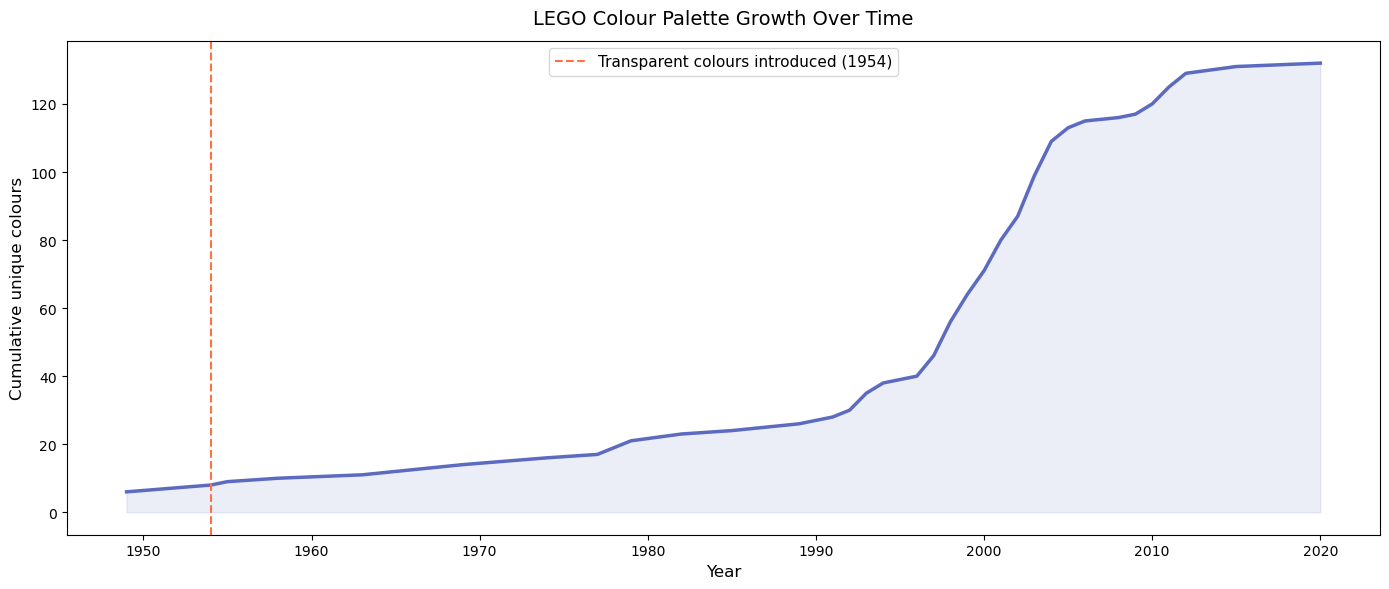

In [56]:
# unique colours introduced each year (first appearance)
first_appearance = (
    color_year.groupby('color_id')['year'].min()
    .reset_index()
    .rename(columns={'year': 'first_year'})
)
first_appearance = first_appearance.merge(
    colors.rename(columns={'id': 'color_id'})[['color_id', 'name', 'rgb', 'is_trans']],
    on='color_id'
)

# palette size by year (cumulative)
cumulative = first_appearance.groupby('first_year').size().cumsum().reset_index()
cumulative.columns = ['year', 'cumulative_colours']

# first year transparent colours appeared
first_trans = first_appearance[first_appearance['is_trans'] == 't']['first_year'].min()
print(f'Transparent colours first appeared in: {first_trans}')
print(f'Total unique colours used in sets: {len(first_appearance)}')

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cumulative['year'], cumulative['cumulative_colours'],
        color='#5C6BC0', linewidth=2.5)
ax.axvline(first_trans, color='#FF7043', linestyle='--', linewidth=1.5,
           label=f'Transparent colours introduced ({first_trans})')
ax.fill_between(cumulative['year'], cumulative['cumulative_colours'],
                alpha=0.12, color='#5C6BC0')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Cumulative unique colours', fontsize=12)
ax.set_title('LEGO Colour Palette Growth Over Time', fontsize=14, pad=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../../plots/colour_palette_growth.png', dpi=150)
plt.show()


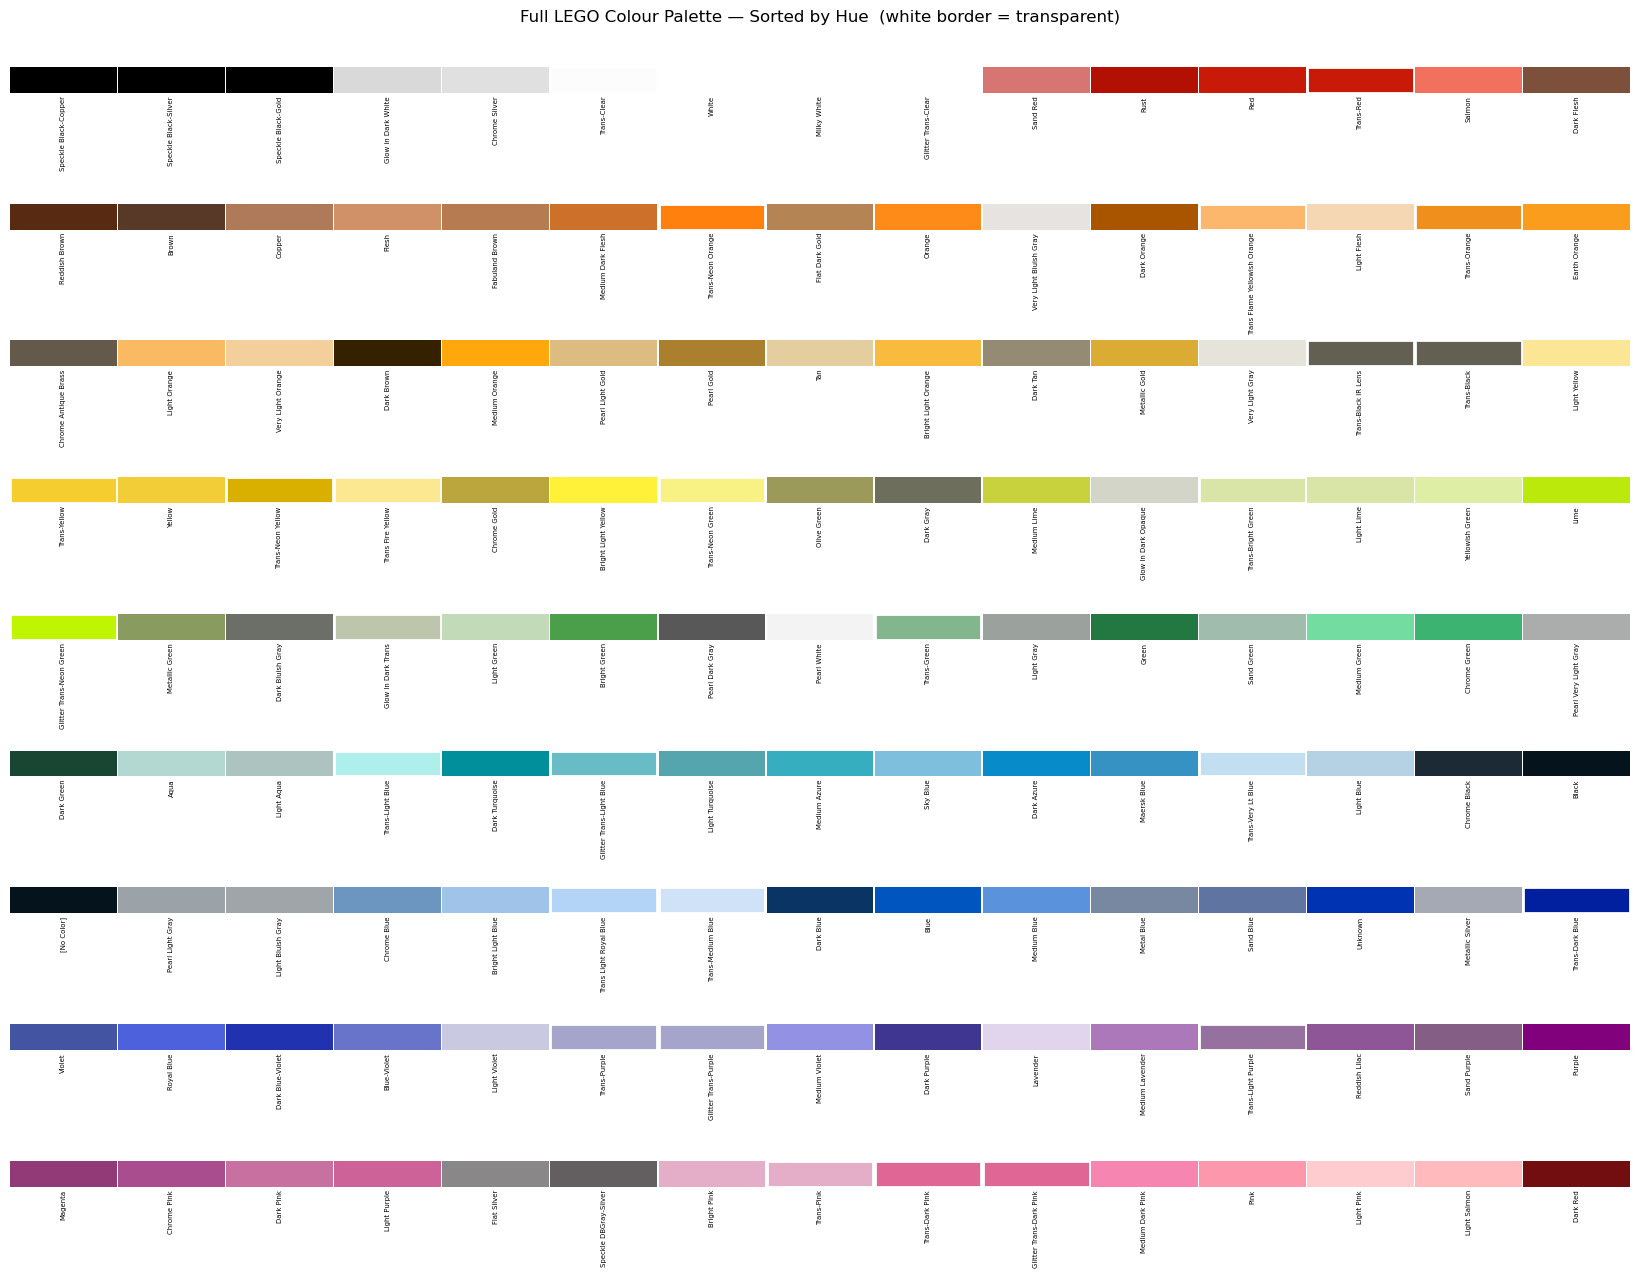

In [57]:
# palette swatches sorted by hue — the current full catalogue
def hex_to_rgb(h):
    h = str(h).strip().lstrip('#')
    if len(h) != 6:
        return (0.5, 0.5, 0.5)
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))

colors_plot = colors.copy()
colors_plot['rgb_float'] = colors_plot['rgb'].apply(hex_to_rgb)
colors_plot['hue'] = colors_plot['rgb_float'].apply(lambda c: mcolors.rgb_to_hsv(c)[0])
colors_plot['value'] = colors_plot['rgb_float'].apply(lambda c: mcolors.rgb_to_hsv(c)[2])
colors_sorted = colors_plot.sort_values(['hue', 'value']).reset_index(drop=True)

n = len(colors_sorted)
cols_per_row = 15
n_rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row,
                          figsize=(cols_per_row * 1.1, n_rows * 1.4))
axes = axes.flatten()
for i, (_, row) in enumerate(colors_sorted.iterrows()):
    ax = axes[i]
    ax.set_facecolor(row['rgb_float'])
    border_color = 'white' if row['is_trans'] == 't' else 'none'
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2 if row['is_trans'] == 't' else 0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(row['name'], fontsize=5, labelpad=2, rotation=90)
for i in range(n, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Full LEGO Colour Palette — Sorted by Hue  (white border = transparent)',
             fontsize=12, y=1.01)
plt.tight_layout(h_pad=0.4, w_pad=0.1)
plt.savefig('../../plots/colour_palette_swatches.png', dpi=150, bbox_inches='tight')
plt.show()


New colours introduced by decade:
 decade  new_colours
   1940            6
   1950            4
   1960            4
   1970            7
   1980            5
   1990           38
   2000           53
   2010           14
   2020            1


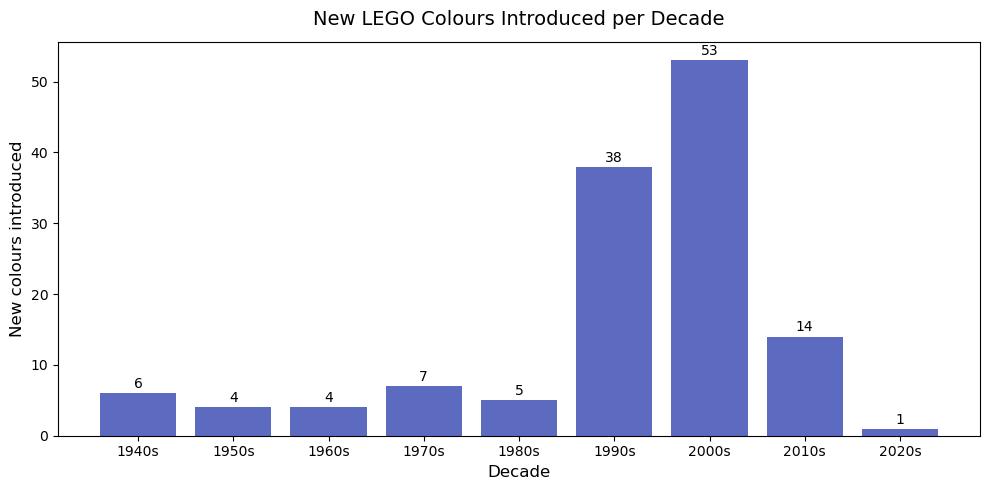

In [58]:
# decade-by-decade palette: which colours were introduced each decade
first_appearance['decade'] = (first_appearance['first_year'] // 10) * 10
decade_intro = first_appearance.groupby('decade').size().reset_index(name='new_colours')
print('New colours introduced by decade:')
print(decade_intro.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(decade_intro['decade'].astype(str) + 's',
       decade_intro['new_colours'],
       color='#5C6BC0', edgecolor='none')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('New colours introduced', fontsize=12)
ax.set_title('New LEGO Colours Introduced per Decade', fontsize=14, pad=12)
for bar, val in zip(ax.patches, decade_intro['new_colours']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../../plots/colour_introductions_by_decade.png', dpi=150)
plt.show()


**Finding:** LEGO's colour vocabulary grew from 6 colours in the 1940s to 132 used in production sets by 2020. Transparent colours first appeared in 1954. The palette remained almost static through the 1970s and 1980s — then exploded: 38 new colours in the 1990s and 53 in the 2000s, the largest single-decade expansion in LEGO's history. That timing is not coincidental: franchise deals required new metallics, flesh tones, and special-effect colours that the original palette did not include. Palette growth and licensed IP share track the same curve.


---
## Analysis 4 — Theme Hierarchy Resolution

**Business question:** Which top-level LEGO product lines have built the largest sub-theme ecosystems, and how deep does the theme hierarchy go?


In [59]:
import numpy as np

parent_map = themes.set_index('id')['parent_id'].to_dict()


def resolve_root(theme_id, depth=0):
    pid = parent_map.get(theme_id)
    if pid is None or (isinstance(pid, float) and np.isnan(pid)):
        return theme_id, depth
    return resolve_root(int(pid), depth + 1)


roots_depths = themes['id'].apply(resolve_root)
themes['root_id'] = [r for r, _ in roots_depths]
themes['depth'] = [d for _, d in roots_depths]

print(f'Maximum hierarchy depth: {themes["depth"].max()}')
deepest = themes[themes['depth'] == themes['depth'].max()][['id', 'name', 'depth']]
print(deepest.to_string(index=False))


Maximum hierarchy depth: 2
 id                  name  depth
  6               Airport      2
  7          Construction      2
  8                  Farm      2
  9                  Fire      2
 10                Harbor      2
 11              Off-Road      2
 12                  Race      2
 13          Riding Cycle      2
 14                 Robot      2
 15               Traffic      2
 24               Airport      2
 25                Castle      2
 26          Construction      2
 27                  Race      2
 28                Harbor      2
 29                 Train      2
 30               Traffic      2
 31              Creature      2
 32                 Robot      2
 33          Food & Drink      2
 34              Building      2
 35                 Cargo      2
 39               Traffic      2
 40              Creature      2
 42               Airport      2
 43              Building      2
 44            Recreation      2
 45                 Cargo      2
 46             

In [60]:
# top-level themes by total sets across all children
root_name_map = themes[themes['id'] == themes['root_id']].set_index('id')['name'].to_dict()

sets_rooted = sets.merge(themes[['id', 'root_id']].rename(columns={'id': 'theme_id'}),
                          on='theme_id', how='left')
root_counts = (
    sets_rooted.groupby('root_id')['set_num'].count()
    .reset_index(name='total_sets')
)
root_counts['theme'] = root_counts['root_id'].map(root_name_map)
root_counts = root_counts.sort_values('total_sets', ascending=False)

print('Top 15 parent themes by total set count:')
print(root_counts[['theme', 'total_sets']].head(15).to_string(index=False))


Top 15 parent themes by total set count:
                  theme  total_sets
                   Town        1304
                  Duplo        1268
                   Gear        1049
              Star Wars         791
Collectible Minifigures         709
  Educational and Dacta         660
                Technic         568
                Creator         509
          Service Packs         471
 Universal Building Set         448
                 System         437
               Bionicle         428
                Friends         398
                Ninjago         386
                  Space         332


In [61]:
# parent themes with most sub-themes
sub_counts = (
    themes[themes['parent_id'].notna()]
    .groupby('root_id')['id'].count()
    .reset_index(name='sub_theme_count')
)
sub_counts['theme'] = sub_counts['root_id'].map(root_name_map)
sub_counts = sub_counts.sort_values('sub_theme_count', ascending=False)

print('Top 10 parent themes by sub-theme count:')
print(sub_counts[['theme', 'sub_theme_count']].head(10).to_string(index=False))


Top 10 parent themes by sub-theme count:
                  theme  sub_theme_count
                   Town               61
               Bionicle               38
Collectible Minifigures               33
                  Duplo               33
                Creator               27
  Educational and Dacta               25
                Technic               20
                  Space               20
                 System               18
               Seasonal               16


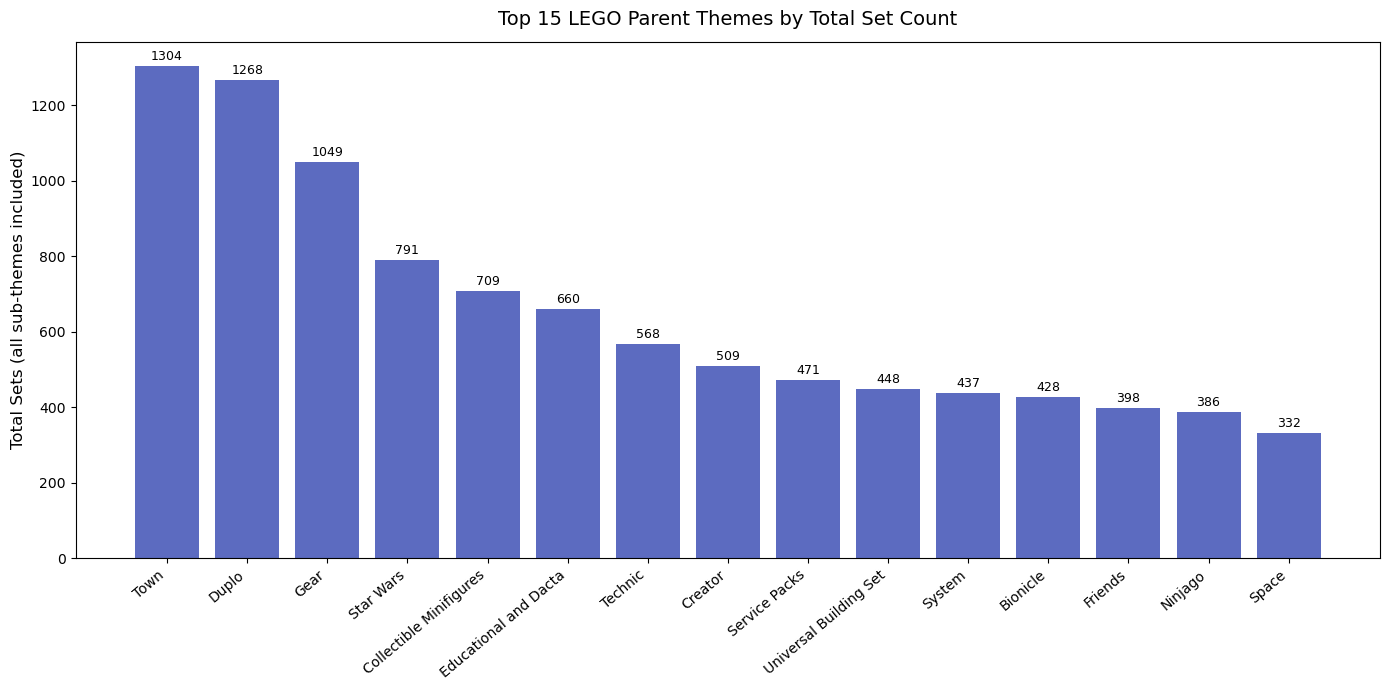

In [62]:
top15 = root_counts.head(15)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(top15)), top15['total_sets'], color='#5C6BC0', edgecolor='none')
ax.set_xticks(range(len(top15)))
ax.set_xticklabels(top15['theme'], rotation=40, ha='right', fontsize=10)
ax.set_ylabel('Total Sets (all sub-themes included)', fontsize=12)
ax.set_title('Top 15 LEGO Parent Themes by Total Set Count', fontsize=14, pad=12)
for bar, val in zip(bars, top15['total_sets']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
            str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../../plots/theme_hierarchy_top15.png', dpi=150)
plt.show()


**Finding:** The theme hierarchy reaches a maximum depth of 2 levels — LEGO's taxonomy is broad rather than deep. When sets are aggregated to root parents, Town leads with 1,304 sets, followed by Duplo (1,268) and Gear (1,049). Note that Gear is a catch-all category for non-brick merchandise — clothing, accessories, storage — rather than a construction product line. Excluding it, Star Wars ranks third with 791 sets despite spanning only 22 years of production. Technic leads on sub-theme count, reflecting decades of product line expansion into increasingly specialised engineering sub-categories.


---
## Analysis 5 — Decade Summary

**Business question:** How has every key metric — volume, diversity, complexity, and licensed share — shifted across LEGO's seven decades of production?


In [63]:
sets_full = sets_ip.copy()
sets_full['decade'] = (sets_full['year'] // 10) * 10

rows = []
for decade, grp in sets_full.groupby('decade'):
    most_popular = (
        grp.groupby('theme_name')['set_num'].count().idxmax()
        if grp['theme_name'].notna().any() else 'N/A'
    )
    rows.append({
        'Decade': f'{decade}s',
        'Total Sets': len(grp),
        'Unique Themes': grp['theme_id'].nunique(),
        'Avg Parts': round(grp['num_parts'].mean(), 1),
        'Most Popular Theme': most_popular,
        '% Licensed': round((grp['ip_type'] == 'Licensed').mean() * 100, 1),
    })

decade_df = pd.DataFrame(rows)
print(decade_df.to_string(index=False))


Decade  Total Sets  Unique Themes  Avg Parts Most Popular Theme  % Licensed
 1940s           5              2       99.6             System         0.0
 1950s         135              6       32.3       Supplemental         0.0
 1960s         376             37       73.8       Supplemental         0.0
 1970s         620             62      107.8          Basic Set         0.0
 1980s        1212             91       90.4      Service Packs         0.0
 1990s        2041            170      124.7            Technic         0.7
 2000s        3831            279      166.4          Basic Set         8.5
 2010s        6813            254      195.6               Gear        20.6
 2020s         677             82      258.6            Friends        21.9


In [64]:
numeric_cols = ['Total Sets', 'Unique Themes', 'Avg Parts', '% Licensed']

styled = (
    decade_df.style
    .background_gradient(subset=numeric_cols, cmap='Blues')
    .format({'Avg Parts': '{:.1f}', '% Licensed': '{:.1f}%'})
    .set_caption('LEGO Production Summary by Decade')
)
styled


,Decade,Total Sets,Unique Themes,Avg Parts,Most Popular Theme,% Licensed
0,1940s,5,2,99.6,System,0.0%
1,1950s,135,6,32.3,Supplemental,0.0%
2,1960s,376,37,73.8,Supplemental,0.0%
3,1970s,620,62,107.8,Basic Set,0.0%
4,1980s,1212,91,90.4,Service Packs,0.0%
5,1990s,2041,170,124.7,Technic,0.7%
6,2000s,3831,279,166.4,Basic Set,8.5%
7,2010s,6813,254,195.6,Gear,20.6%
8,2020s,677,82,258.6,Friends,21.9%


**Finding:** The decade table maps LEGO's three distinct eras. A low-volume origins phase (1950s–1970s) with minimal theme diversity and simple sets. A rapid expansion phase (1980s–1990s) where theme count and part complexity grew sharply. A licensed IP era (2000s–2020s) where franchise deals drove both volume and average part count to new highs. The % Licensed column shows the exact decade when IP partnerships became the structural backbone of the product line.


---
## Analysis 6 — Minifigures and the Collector Economy

**Business question:** Did the licensed IP era change *what kind of product* LEGO makes — shifting sets from brick-building exercises toward character-collecting experiences?

Minifigure density (figures per 100 parts) is the signal: a rising density means sets are being engineered around characters rather than structures.


In [65]:
inv_minifigs = pd.read_csv('../../data/inventory_minifigs.csv')

# join chain: inventory_minifigs → inventories → sets
fig_sets = inv_minifigs.merge(
    inventories[['id', 'set_num']], left_on='inventory_id', right_on='id'
)
fig_sets = fig_sets.merge(
    sets_ip[['set_num', 'year', 'theme_name', 'ip_type', 'num_parts']],
    on='set_num'
)

# unique fig types and total figs per set
unique_figs = fig_sets.groupby('set_num')['fig_num'].nunique().reset_index(name='unique_fig_types')
total_figs  = fig_sets.groupby('set_num')['quantity'].sum().reset_index(name='total_figs')
set_figs = unique_figs.merge(total_figs, on='set_num')
set_figs = set_figs.merge(
    sets_ip[['set_num', 'year', 'theme_name', 'ip_type', 'num_parts']], on='set_num'
)
set_figs = set_figs[set_figs['num_parts'] > 0].copy()
set_figs['figs_per_100_parts'] = set_figs['total_figs'] / set_figs['num_parts'] * 100
set_figs['decade'] = (set_figs['year'] // 10) * 10

print(f'Sets with at least one minifig: {len(set_figs):,} '
      f'({len(set_figs)/len(sets)*100:.1f}% of all sets)')
print()
print('Licensed vs Original — avg unique fig types per set:')
print(set_figs.groupby('ip_type')[['unique_fig_types', 'total_figs', 'figs_per_100_parts']]
      .mean().round(2))


Sets with at least one minifig: 6,204 (39.5% of all sets)

Licensed vs Original — avg unique fig types per set:
          unique_fig_types  total_figs  figs_per_100_parts
ip_type                                                   
Licensed              2.86        3.41                4.85
Original              2.37        2.84                4.75


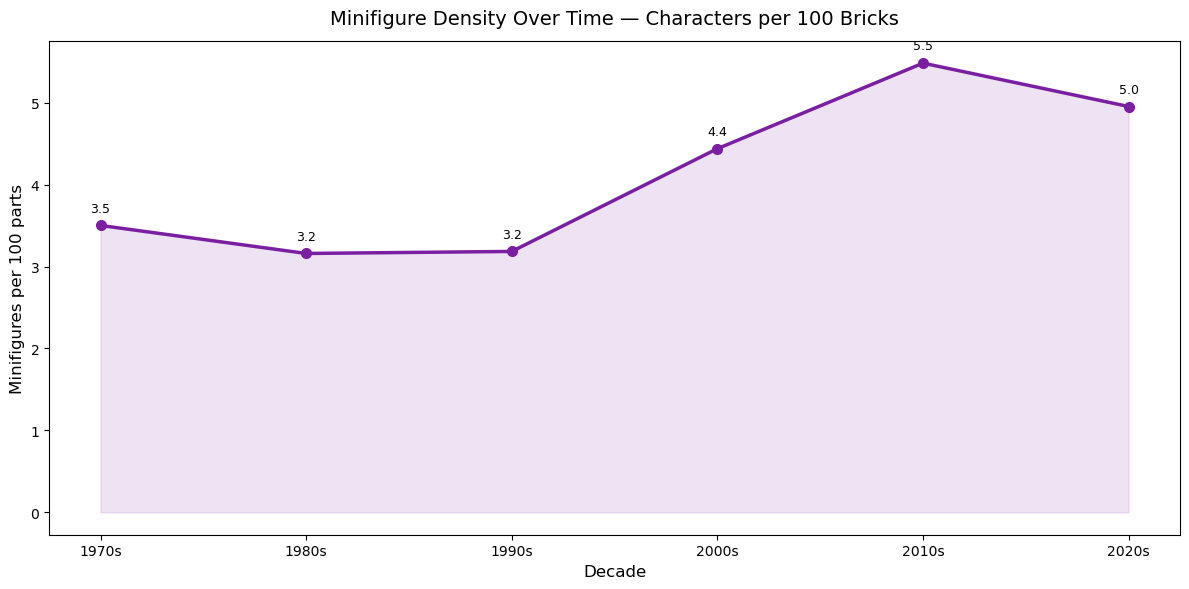

In [66]:
# fig density by decade — the core trend line
density_by_decade = set_figs.groupby('decade')['figs_per_100_parts'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(density_by_decade.index, density_by_decade.values,
        color='#7B1FA2', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(density_by_decade.index, density_by_decade.values,
                alpha=0.12, color='#7B1FA2')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Minifigures per 100 parts', fontsize=12)
ax.set_title('Minifigure Density Over Time — Characters per 100 Bricks', fontsize=14, pad=12)
ax.set_xticks(density_by_decade.index)
ax.set_xticklabels([f'{d}s' for d in density_by_decade.index], fontsize=10)
for x, y in zip(density_by_decade.index, density_by_decade.values):
    ax.annotate(f'{y:.1f}', (x, y), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../plots/minifig_density_by_decade.png', dpi=150)
plt.show()


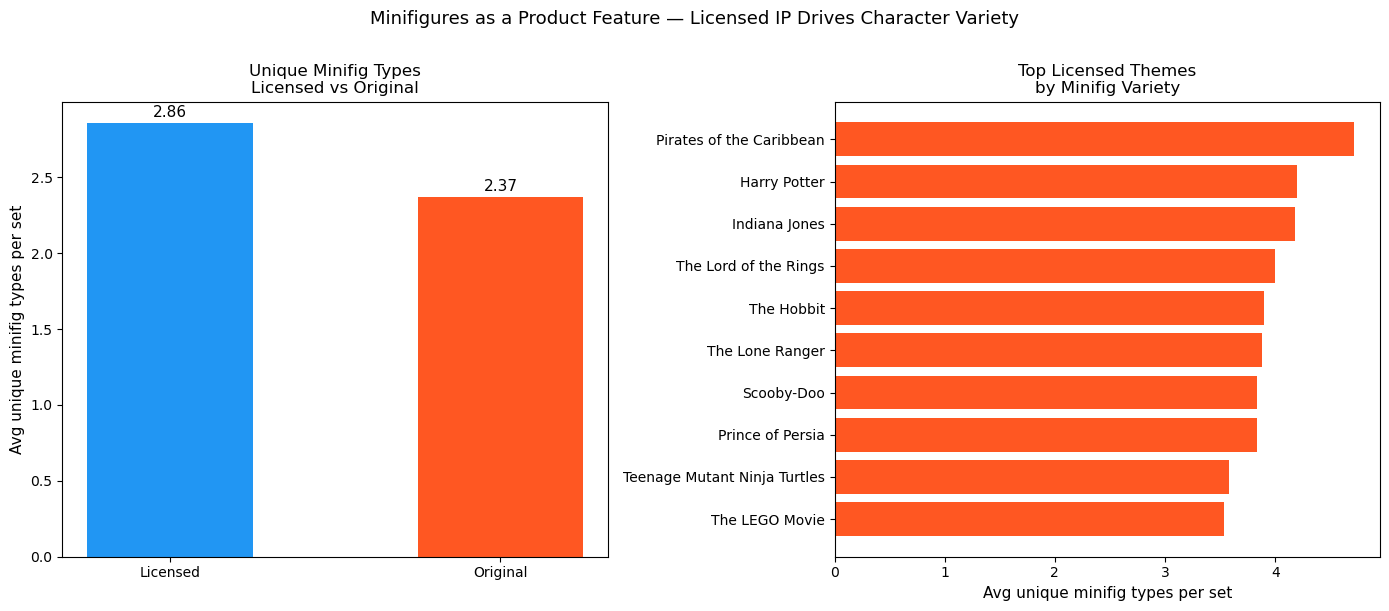

In [67]:
# licensed vs original: distribution of unique fig types per set
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: avg unique fig types — licensed vs original
ip_means = set_figs.groupby('ip_type')['unique_fig_types'].mean()
colors_bar = ['#2196F3', '#FF5722']
axes[0].bar(ip_means.index, ip_means.values, color=colors_bar, edgecolor='none', width=0.5)
axes[0].set_ylabel('Avg unique minifig types per set', fontsize=11)
axes[0].set_title('Unique Minifig Types\nLicensed vs Original', fontsize=12)
for i, (label, val) in enumerate(ip_means.items()):
    axes[0].text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=11)

# right: top 10 licensed themes by avg unique fig types (min 10 sets)
top_lic = (
    set_figs[set_figs['ip_type'] == 'Licensed']
    .groupby('theme_name')
    .agg(avg_unique=('unique_fig_types', 'mean'), set_count=('set_num', 'count'))
    .query('set_count >= 5')
    .sort_values('avg_unique', ascending=False)
    .head(10)
)
axes[1].barh(range(len(top_lic)), top_lic['avg_unique'][::-1],
             color='#FF5722', edgecolor='none')
axes[1].set_yticks(range(len(top_lic)))
axes[1].set_yticklabels(top_lic.index[::-1], fontsize=10)
axes[1].set_xlabel('Avg unique minifig types per set', fontsize=11)
axes[1].set_title('Top Licensed Themes\nby Minifig Variety', fontsize=12)

plt.suptitle('Minifigures as a Product Feature — Licensed IP Drives Character Variety',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../plots/minifig_licensed_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()


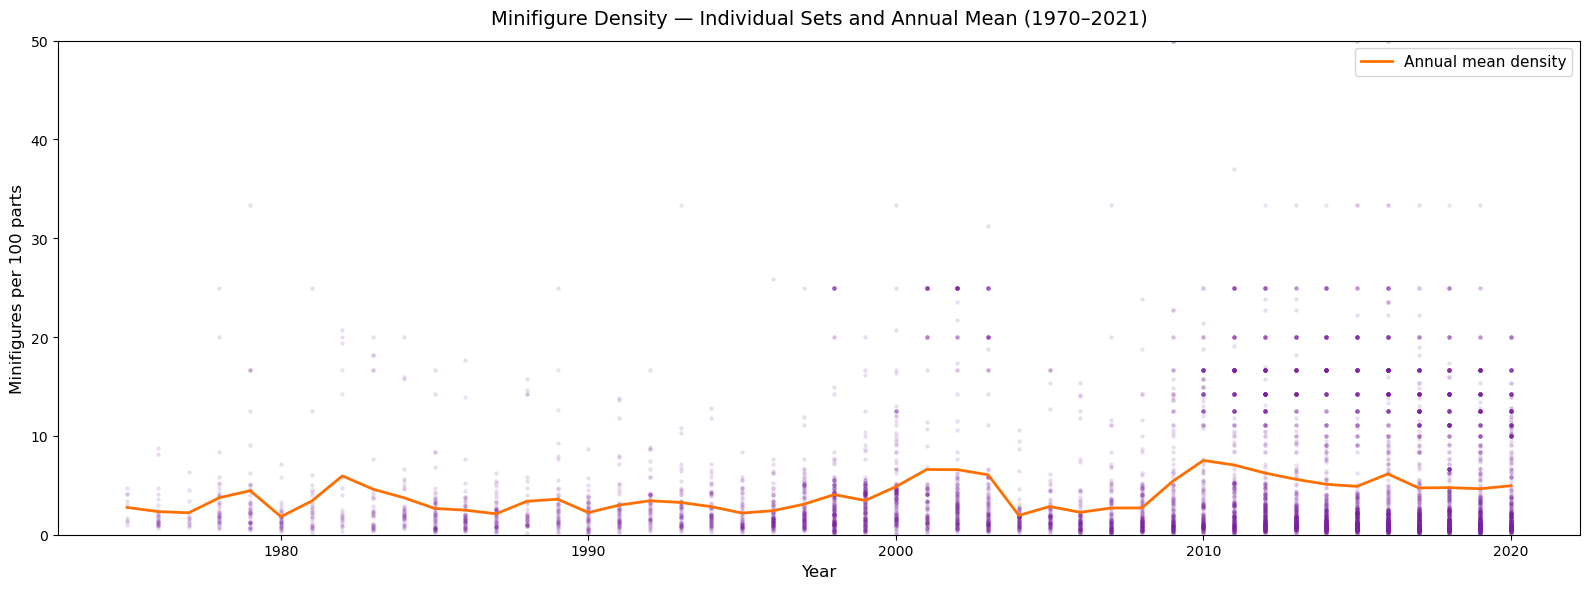

In [68]:
# year-on-year density scatter (all sets with figs, 1970 onwards)
set_figs_1970 = set_figs[set_figs['year'] >= 1970]
annual_density = set_figs_1970.groupby('year')['figs_per_100_parts'].mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(set_figs_1970['year'], set_figs_1970['figs_per_100_parts'],
           alpha=0.15, s=10, color='#7B1FA2', linewidths=0)
ax.plot(annual_density.index, annual_density.values,
        color='#FF6F00', linewidth=2, label='Annual mean density')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Minifigures per 100 parts', fontsize=12)
ax.set_title('Minifigure Density — Individual Sets and Annual Mean (1970–2021)', fontsize=14, pad=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.savefig('../../plots/minifig_density_scatter.png', dpi=150)
plt.show()


**Finding:** Minifigure density grew 57% from 3.5 figures per 100 parts in the 1970s to 5.5 in the 2010s — a structural shift in what LEGO sets are built around. Licensed sets average 2.86 unique character types per set versus 2.37 for original IP, a 21% premium in character variety. The effect is strongest in narrative-driven franchises: Pirates of the Caribbean leads licensed themes at 4.7 unique fig types per set, followed by Harry Potter (4.2) and Indiana Jones (4.2). The density trend and the licensed IP share trend move in lockstep from the 2000s onward — sets became more character-focused at precisely the moment franchise deals scaled up.
